# Clickbait Spoiling — Exploratory Data Analysis

In [1]:
import json
import os
import re
import textwrap
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.autolayout"] = True

TYPE_ORDER = ["phrase", "passage", "multi"]
TYPE_COLORS = dict(zip(TYPE_ORDER, sns.color_palette("Set2", 3)))


## 1. Load Data & Basic Counts

In [2]:
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

train = load_jsonl("task1/train.jsonl")
val   = load_jsonl("task1/val.jsonl")
test  = load_jsonl("task1/test.jsonl")

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print(f"Total: {len(train) + len(val) + len(test)}")

# Task 1 and Task 2 ship the identical underlying corpus -- confirm rather than assume.
import hashlib
def md5(path):
    return hashlib.md5(open(path, "rb").read()).hexdigest()

for split in ["train", "val", "test"]:
    same = md5(f"task1/{split}.jsonl") == md5(f"task2/{split}.jsonl")
    print(f"task1/{split}.jsonl == task2/{split}.jsonl : {same}")


Train: 3200 | Val: 400 | Test: 400
Total: 4000
task1/train.jsonl == task2/train.jsonl : True
task1/val.jsonl == task2/val.jsonl : True
task1/test.jsonl == task2/test.jsonl : True


### Record schema
One raw training record, showing every field the harness has access to (media URLs truncated).

In [3]:
example = train[0]
shown = {k: (v[:2] + ["..."] if k == "targetMedia" and len(v) > 2 else v) for k, v in example.items()}
for k, v in shown.items():
    text = json.dumps(v, indent=2) if not isinstance(v, str) else v
    print(f"{k}:")
    print(textwrap.indent(textwrap.shorten(str(v), width=300, placeholder=" ..."), "  "))
    print()


uuid:
  0af11f6b-c889-4520-9372-66ba25cb7657

postId:
  532quh

postText:
  ['Wes Welker Wanted Dinner With Tom Brady, But Patriots QB Had Better Idea']

postPlatform:
  reddit

targetParagraphs:
  ['It’ll be just like old times this weekend for Tom Brady and Wes Welker.', 'Welker revealed Friday morning on a Miami radio station that he contacted Brady because he’ll be in town for Sunday’s game between the New England Patriots and Miami Dolphins at Gillette Stadium. It seemed like a ...

targetTitle:
  Wes Welker Wanted Dinner With Tom Brady, But Patriots QB Had A Better Idea

targetDescription:
  It'll be just like old times this weekend for Tom Brady and Wes Welker. Welker revealed Friday morning on a Miami radio station that he contacted Brady because he'll be in town for Sunday's game between the New England Patriots and Miami Dolphins at Gillette Stadium.

targetKeywords:
  new england patriots, ricky doyle, top stories,

targetMedia:
  ['http://pixel.wp.com/b.gif?v=noscript', 'ht

## 2. Task 1: Spoiler Type Distribution

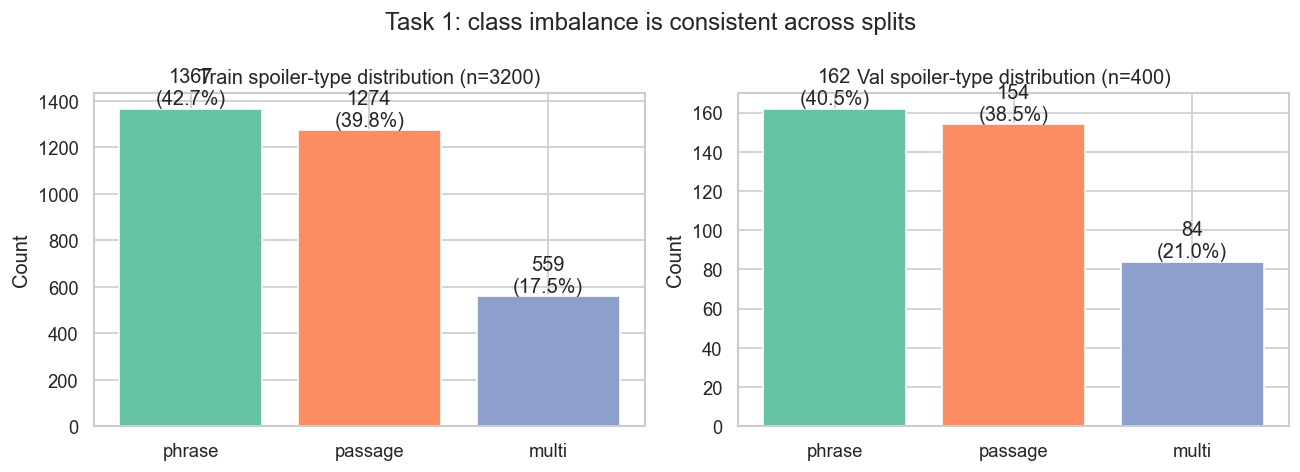

Train %:
 label
phrase     42.7
passage    39.8
multi      17.5
Name: proportion, dtype: float64


In [4]:
def to_df(records, has_labels=True):
    rows = []
    for r in records:
        row = {
            "postText": r["postText"][0] if r["postText"] else "",
            "targetTitle": r.get("targetTitle", ""),
            "targetDescription": r.get("targetDescription", ""),
            "targetParagraphs": r.get("targetParagraphs", []),
            "n_paragraphs": len(r.get("targetParagraphs", [])),
            "platform": r.get("postPlatform", ""),
        }
        if has_labels:
            row["label"] = r["tags"][0]
            row["spoiler"] = r["spoiler"]
            row["n_spoilers"] = len(r["spoiler"])
            row["spoilerPositions"] = r.get("spoilerPositions", [])
        rows.append(row)
    return pd.DataFrame(rows)

train_df = to_df(train)
val_df = to_df(val)
test_df = to_df(test, has_labels=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (df, split) in zip(axes, [(train_df, "Train"), (val_df, "Val")]):
    counts = df["label"].value_counts().reindex(TYPE_ORDER)
    bars = ax.bar(counts.index, counts.values, color=[TYPE_COLORS[t] for t in TYPE_ORDER])
    pct = counts / counts.sum() * 100
    ax.bar_label(bars, labels=[f"{c}\n({p:.1f}%)" for c, p in zip(counts, pct)])
    ax.set_title(f"{split} spoiler-type distribution (n={len(df)})")
    ax.set_ylabel("Count")
plt.suptitle("Task 1: class imbalance is consistent across splits")
plt.tight_layout()
plt.show()

print("Train %:\n", (train_df["label"].value_counts(normalize=True) * 100).round(1))


## 3. Text Length Analysis

How long are the headline, title, description, and article body? This matters for choosing a
sequence length (the report uses 256 tokens for Task 1, 384 for Task 2's sliding-window QA) and
for the title-only-vs-full-article input decision.

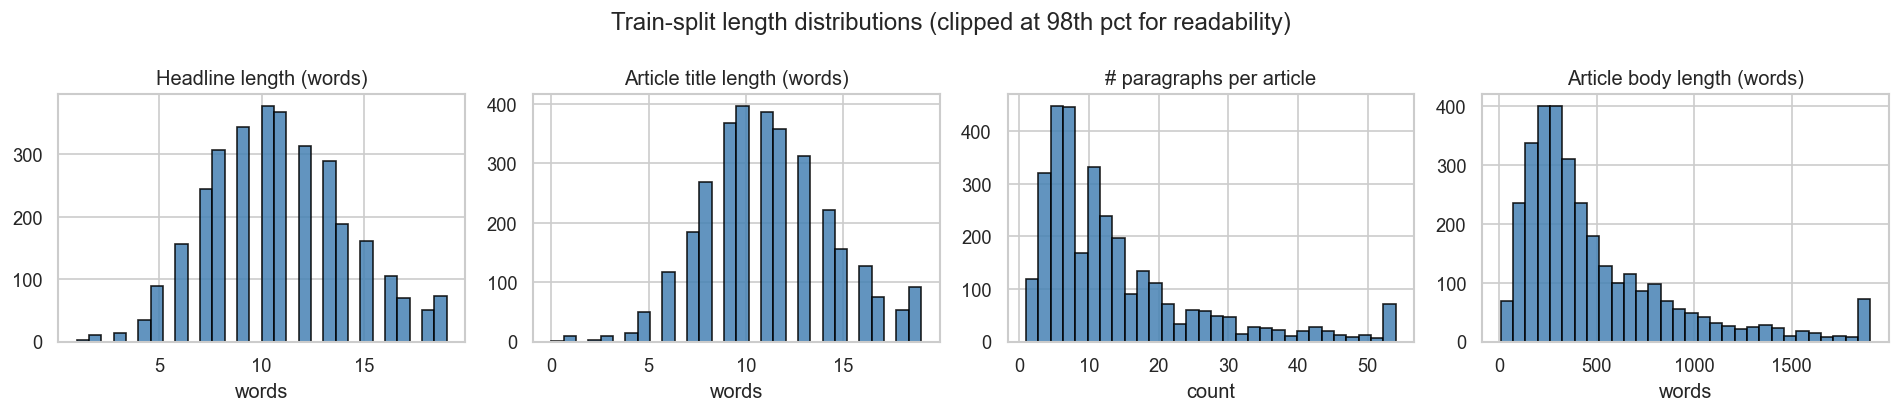

,headline_words,title_words,desc_words,n_paragraphs,article_words
count,3200.0,3200.0,2933.0,3200.0,3200.0
mean,10.8,11.3,22.8,14.2,514.8
std,3.5,3.5,47.3,14.2,583.4
min,1.0,0.0,0.0,1.0,7.0
25%,8.0,9.0,12.0,6.0,222.0
50%,11.0,11.0,20.0,10.0,352.5
75%,13.0,13.0,27.0,17.0,642.2
max,28.0,33.0,2372.0,249.0,14059.0


In [5]:
for df in (train_df, val_df):
    df["headline_words"] = df["postText"].str.split().str.len()
    df["title_words"] = df["targetTitle"].str.split().str.len()
    df["desc_words"] = df["targetDescription"].str.split().str.len()
    df["article_words"] = df["targetParagraphs"].apply(lambda ps: sum(len(p.split()) for p in ps))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
specs = [("headline_words", "Headline length (words)"),
         ("title_words", "Article title length (words)"),
         ("n_paragraphs", "# paragraphs per article"),
         ("article_words", "Article body length (words)")]
for ax, (col, title) in zip(axes, specs):
    ax.hist(train_df[col].clip(upper=train_df[col].quantile(0.98)), bins=30,
            color="steelblue", edgecolor="black", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("words" if "word" in title else "count")
plt.suptitle("Train-split length distributions (clipped at 98th pct for readability)")
plt.tight_layout()
plt.show()

train_df[["headline_words", "title_words", "desc_words", "n_paragraphs", "article_words"]].describe().round(1)


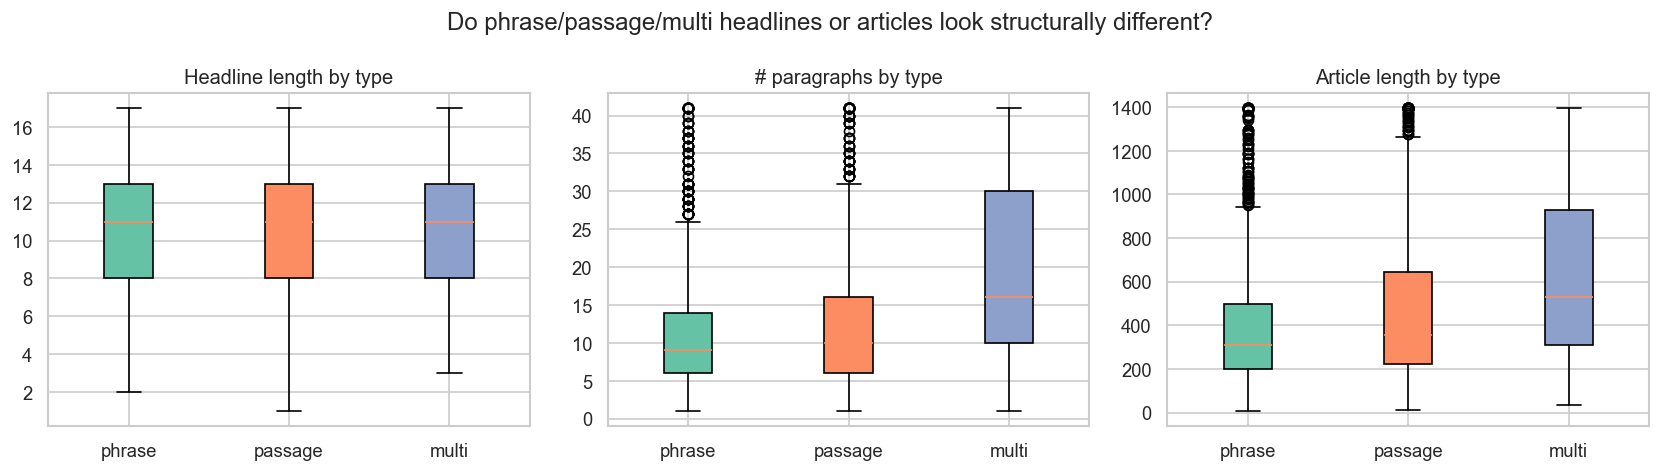

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(
    axes,
    ["headline_words", "n_paragraphs", "article_words"],
    ["Headline length by type", "# paragraphs by type", "Article length by type"],
):
    data = [train_df.loc[train_df.label == t, col].clip(upper=train_df[col].quantile(0.95)) for t in TYPE_ORDER]
    bp = ax.boxplot(data, tick_labels=TYPE_ORDER, patch_artist=True)
    for patch, t in zip(bp["boxes"], TYPE_ORDER):
        patch.set_facecolor(TYPE_COLORS[t])
    ax.set_title(title)
plt.suptitle("Do phrase/passage/multi headlines or articles look structurally different?")
plt.tight_layout()
plt.show()


## 4. Spoiler Verbatim Presence in the Article

In [7]:
def build_context(r):
    parts = [r.get("targetTitle", "")] + r.get("targetParagraphs", [])
    return " ".join(p for p in parts if p)

def spoiler_is_verbatim(r):
    ctx = build_context(r)
    hits = 0
    for s in r.get("spoiler", []):
        s = s.strip()
        if not s:
            continue
        if s in ctx or " ".join(s.split()) in ctx:
            hits += 1
    n = len([s for s in r.get("spoiler", []) if s.strip()])
    return hits, n

verbatim_hits = verbatim_total = 0
by_type = {t: [0, 0] for t in TYPE_ORDER}
for r in train:
    h, n = spoiler_is_verbatim(r)
    verbatim_hits += h
    verbatim_total += n
    t = r["tags"][0]
    by_type[t][0] += h
    by_type[t][1] += n

print(f"Overall: {verbatim_hits}/{verbatim_total} spoiler segments found verbatim "
      f"in the article = {verbatim_hits/verbatim_total*100:.1f}%")
print("\nBy type:")
for t in TYPE_ORDER:
    h, n = by_type[t]
    print(f"  {t:8s}: {h}/{n} = {h/n*100:.1f}%")


Overall: 4608/4622 spoiler segments found verbatim in the article = 99.7%

By type:
  phrase  : 1367/1367 = 100.0%
  passage : 1274/1274 = 100.0%
  multi   : 1967/1981 = 99.3%


## 5. Spoiler Length & Multi-Part Structure

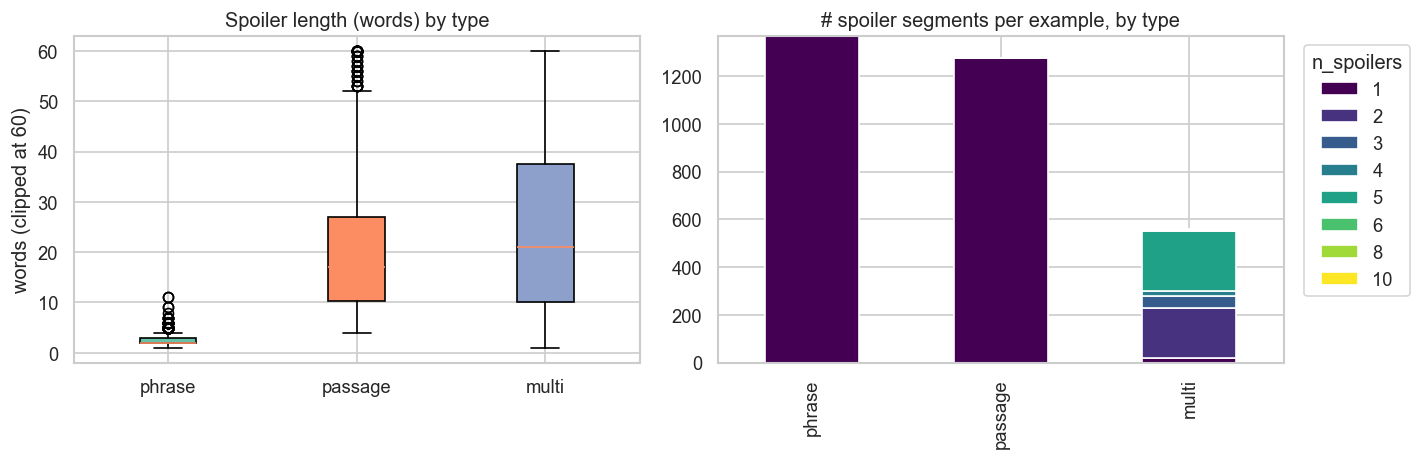

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
phrase,1367.0,2.5,1.3,1.0,2.0,2.0,3.0,11.0
passage,1274.0,21.2,16.3,4.0,10.2,17.0,27.0,174.0
multi,559.0,29.1,29.3,1.0,10.0,21.0,37.5,255.0


In [8]:
train_df["spoiler_words"] = train_df["spoiler"].apply(lambda s: sum(len(x.split()) for x in s))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data = [train_df.loc[train_df.label == t, "spoiler_words"].clip(upper=60) for t in TYPE_ORDER]
bp = axes[0].boxplot(data, tick_labels=TYPE_ORDER, patch_artist=True)
for patch, t in zip(bp["boxes"], TYPE_ORDER):
    patch.set_facecolor(TYPE_COLORS[t])
axes[0].set_title("Spoiler length (words) by type")
axes[0].set_ylabel("words (clipped at 60)")

n_spoilers_by_type = train_df.groupby("label")["n_spoilers"].value_counts().unstack(fill_value=0).reindex(TYPE_ORDER)
n_spoilers_by_type.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("# spoiler segments per example, by type")
axes[1].set_xlabel("")
axes[1].legend(title="n_spoilers", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

train_df.groupby("label")["spoiler_words"].describe().round(1).loc[TYPE_ORDER]


**Reading:** `phrase` is tightly clustered at a few words, `passage` is long and much more
variable (a full sentence or paragraph), and `multi` is the only type where `n_spoilers > 1` is
common. This is exactly the structure the report's type-conditioned decoding rule exploits.

## 6. Headline Surface-Style


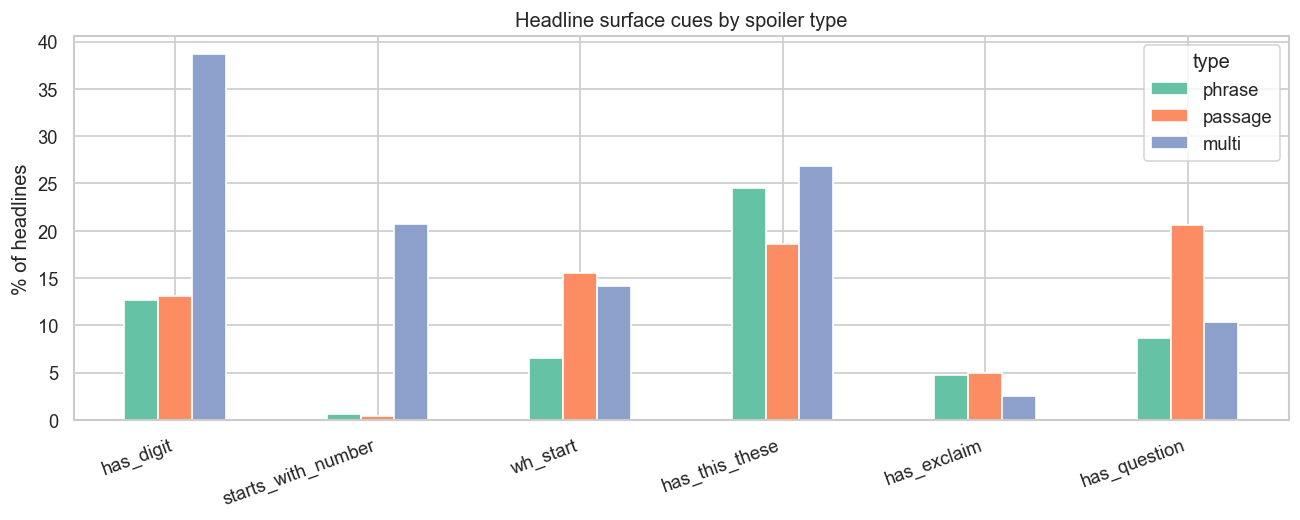

,has_digit,starts_with_number,wh_start,has_this_these,has_exclaim,has_question
label,,,,,,
phrase,12.7,0.6,6.5,24.5,4.8,8.7
passage,13.1,0.4,15.5,18.6,4.9,20.6
multi,38.6,20.8,14.1,26.8,2.5,10.4


In [9]:
def cue_features(text):
    t = text.strip()
    words = t.split()
    return {
        "has_digit": any(ch.isdigit() for ch in t),
        "starts_with_number": bool(words) and words[0].rstrip(".:").isdigit(),
        "wh_start": bool(words) and words[0].lower().strip(string_punct) in
                    ("what", "why", "how", "who", "where", "when", "which"),
        "has_this_these": any(w.lower().strip(string_punct) in ("this", "these") for w in words),
        "has_exclaim": "!" in t,
        "has_question": "?" in t,
        "n_caps_words": sum(1 for w in words if w.isupper() and len(w) > 1),
    }

import string as _string
string_punct = _string.punctuation

cue_rows = []
for _, row in train_df.iterrows():
    feats = cue_features(row["postText"])
    feats["label"] = row["label"]
    cue_rows.append(feats)
cue_df = pd.DataFrame(cue_rows)

bool_cols = ["has_digit", "starts_with_number", "wh_start", "has_this_these", "has_exclaim", "has_question"]
rates = cue_df.groupby("label")[bool_cols].mean().reindex(TYPE_ORDER) * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
rates.T.plot(kind="bar", ax=ax, color=[TYPE_COLORS[t] for t in TYPE_ORDER])
ax.set_ylabel("% of headlines")
ax.set_title("Headline surface cues by spoiler type")
ax.legend(title="type")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

rates.round(1)


**Reading:** headlines containing a digit or starting with a number ("11 things...") skew
noticeably toward `multi` (a listicle headline usually spoils into several list items), while
wh-word openers ("What...", "How...") are common but fairly even across types. These are exactly
the kind of surface regularities that word- and character-level n-grams pick up automatically —
they don't need to be hand-coded, but seeing them here explains *why* the n-gram baseline works.

## 7. Preprocessing Rationale — Noise in the Raw Text

The report's biggest single Task 1 improvement (+0.027 test weighted F1, more than the jump from
RoBERTa to a weighted loss) is a text-cleaning step: stripping hyperlinks, replacing hashtags and
@mentions with placeholders, removing emojis, and expanding contractions. That step only helps if
this noise is actually present in the data — we check how common each artifact is.

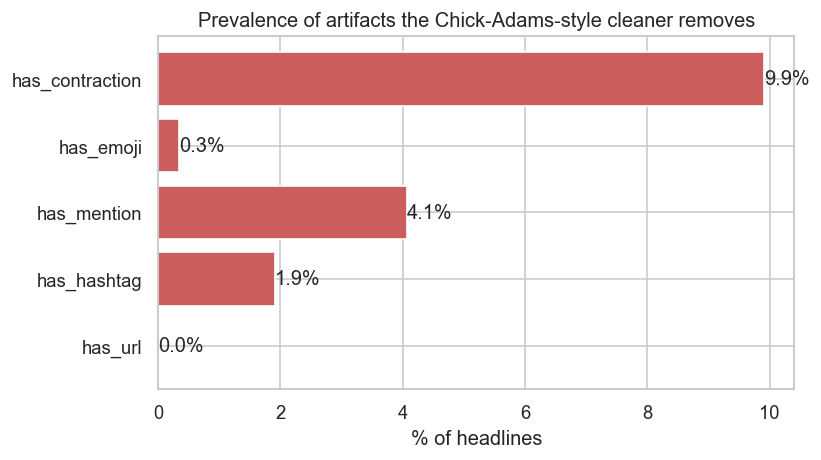

has_url            0.00
has_hashtag        1.91
has_mention        4.06
has_emoji          0.34
has_contraction    9.91
dtype: float64

In [10]:
_EMOJI = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF"
                     "\U0001F1E6-\U0001F1FF\U00002B00-\U00002BFF]", flags=re.UNICODE)
_CONTRACTIONS_RE = re.compile(r"\b\w+n't\b|\b\w+'re\b|\b\w+'ll\b|\b\w+'ve\b|\b\w+'m\b", re.IGNORECASE)

def noise_features(text):
    return {
        "has_url": bool(re.search(r"https?://\S+|www\.\S+", text)),
        "has_hashtag": bool(re.search(r"#\w+", text)),
        "has_mention": bool(re.search(r"@\w+", text)),
        "has_emoji": bool(_EMOJI.search(text)),
        "has_contraction": bool(_CONTRACTIONS_RE.search(text)),
    }

noise_rows = [noise_features(t) for t in train_df["postText"]]
noise_df = pd.DataFrame(noise_rows)
noise_rates = noise_df.mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(noise_rates.index, noise_rates.values, color="indianred")
ax.bar_label(bars, fmt="%.1f%%")
ax.set_xlabel("% of headlines")
ax.set_title("Prevalence of artifacts the Chick-Adams-style cleaner removes")
plt.tight_layout()
plt.show()

noise_rates.round(2)


Even a low prevalence of URLs/hashtags/emojis matters: those tokens are rare enough in
pretraining that a subword tokenizer fragments them unpredictably, injecting noise into exactly
the headlines where it appears. Contractions are common enough that normalizing them (`won't` →
`will not`) meaningfully reduces surface-form variance across otherwise-identical headlines.

## 8. Multi vs. Passage Confusability

The report notes `multi` is the hardest class throughout modeling (per-class F1 0.68 vs. 0.77 for
the other two) and is *"easily confused with the passage type."* We can see a structural reason
why directly in the data: their spoiler-length distributions overlap substantially.

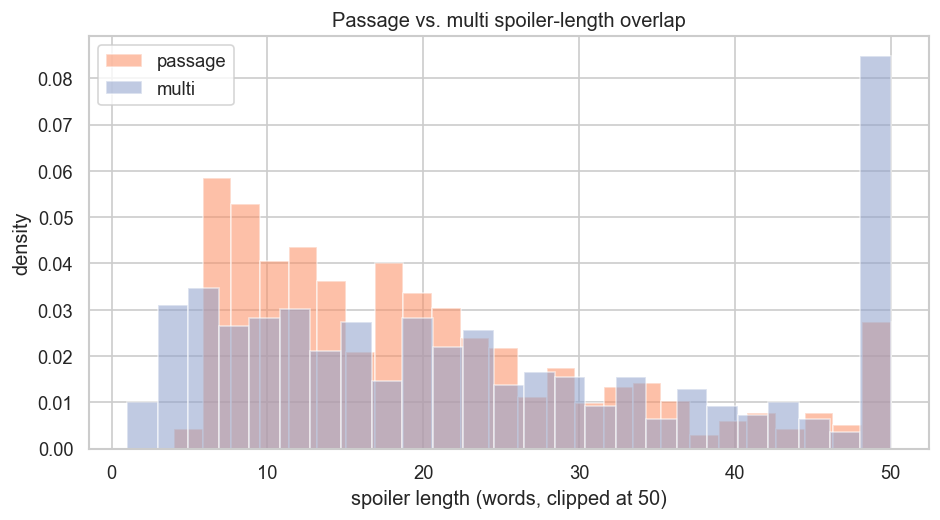

label
passage    628
multi      178
phrase       5
Name: count, dtype: int64

811 examples fall in the 8-20 word band where passage and multi are hardest to tell apart by length alone.


In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for t, color in [("passage", TYPE_COLORS["passage"]), ("multi", TYPE_COLORS["multi"])]:
    vals = train_df.loc[train_df.label == t, "spoiler_words"].clip(upper=50)
    ax.hist(vals, bins=25, alpha=0.55, label=t, color=color, density=True)
ax.set_xlabel("spoiler length (words, clipped at 50)")
ax.set_ylabel("density")
ax.set_title("Passage vs. multi spoiler-length overlap")
ax.legend()
plt.tight_layout()
plt.show()

# A single joined multi-spoiler can look just as long as a passage spoiler.
overlap_lo, overlap_hi = 8, 20
in_band = train_df["spoiler_words"].between(overlap_lo, overlap_hi)
print(train_df.loc[in_band, "label"].value_counts())
print(f"\n{in_band.sum()} examples fall in the {overlap_lo}-{overlap_hi} word band where "
      f"passage and multi are hardest to tell apart by length alone.")


A several-segment `multi` spoiler, once its segments are joined, can span about as many
words as a short `passage` spoiler — there is no clean length threshold separating them. That
ambiguity is a data property, not a modeling failure, and matches the confusion the report
observes downstream.

## 9. Spoiler Position in the Article

Does the spoiler tend to appear early or late in the article, and does that vary by type?

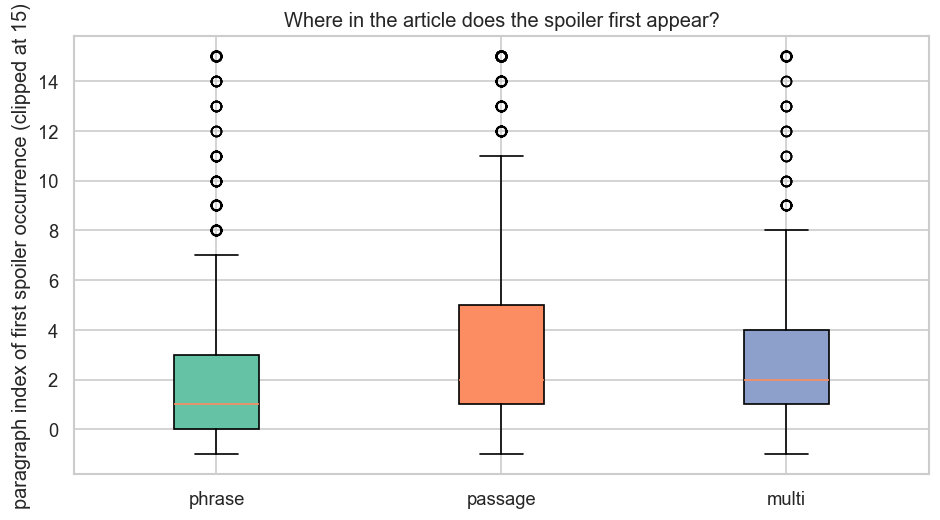

label
multi      2.0
passage    2.0
phrase     1.0
Name: first_paragraph, dtype: float64

In [12]:
para_rows = []
for r in train:
    label = r["tags"][0]
    positions = r.get("spoilerPositions", [])
    if positions:
        first_para = positions[0][0][0]  # paragraph index of the first spoiler's start
        para_rows.append({"label": label, "first_paragraph": first_para})
para_df = pd.DataFrame(para_rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
data = [para_df.loc[para_df.label == t, "first_paragraph"].clip(upper=15) for t in TYPE_ORDER]
bp = ax.boxplot(data, tick_labels=TYPE_ORDER, patch_artist=True)
for patch, t in zip(bp["boxes"], TYPE_ORDER):
    patch.set_facecolor(TYPE_COLORS[t])
ax.set_ylabel("paragraph index of first spoiler occurrence (clipped at 15)")
ax.set_title("Where in the article does the spoiler first appear?")
plt.tight_layout()
plt.show()

para_df.groupby("label")["first_paragraph"].median()


There's no strong early/late skew by type, and spoilers can appear well into the article —
another point in favor of an extractive model that reads the *whole* article (via a sliding
window) rather than only its first few paragraphs.

## 10. Headline–Spoiler Word Overlap

If the answer were already sitting in the headline, spoiling would be trivial. We check how much
vocabulary a spoiler shares with its own headline.

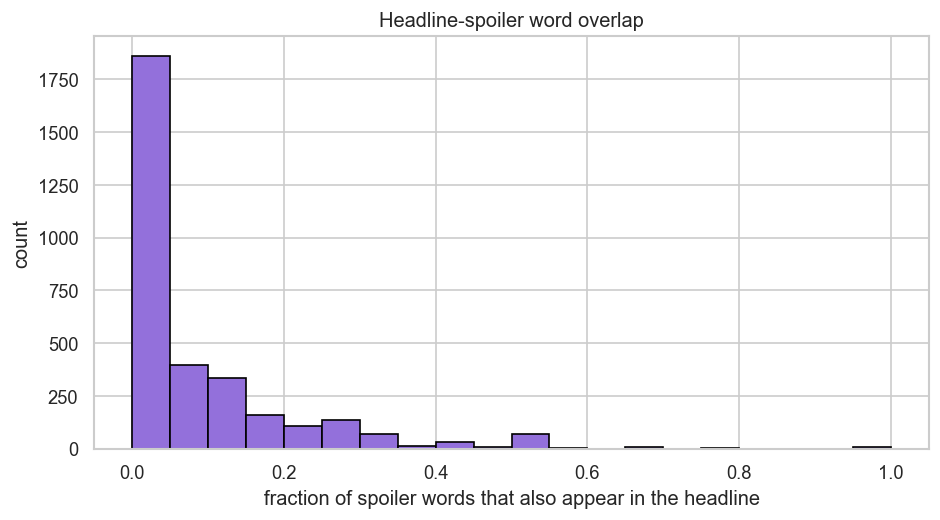

Median overlap: 0.00
Zero-overlap examples: 51.2%


In [13]:
def word_overlap(headline, spoiler_words):
    h_words = set(re.findall(r"\w+", headline.lower()))
    s_words = set(re.findall(r"\w+", spoiler_words.lower()))
    if not s_words:
        return np.nan
    return len(h_words & s_words) / len(s_words)

overlaps = []
for _, row in train_df.iterrows():
    joined_spoiler = " ".join(row["spoiler"])
    overlaps.append(word_overlap(row["postText"], joined_spoiler))
train_df["headline_overlap"] = overlaps

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(train_df["headline_overlap"].dropna(), bins=20, color="mediumpurple", edgecolor="black")
ax.set_xlabel("fraction of spoiler words that also appear in the headline")
ax.set_ylabel("count")
ax.set_title("Headline-spoiler word overlap")
plt.tight_layout()
plt.show()

print(f"Median overlap: {train_df['headline_overlap'].median():.2f}")
print(f"Zero-overlap examples: {(train_df['headline_overlap'] == 0).mean()*100:.1f}%")


Overlap is low and a substantial fraction of examples share *no* words at all with the
headline. The curiosity gap is real in this data, the headline genuinely withholds the answer,
so the model has to read the linked article, not just paraphrase the headline.

## 11. Train / Validation Consistency

In [14]:
compare = pd.DataFrame({
    "train_%": (train_df["label"].value_counts(normalize=True) * 100).reindex(TYPE_ORDER),
    "val_%": (val_df["label"].value_counts(normalize=True) * 100).reindex(TYPE_ORDER),
}).round(1)
compare["abs_diff"] = (compare["train_%"] - compare["val_%"]).abs().round(1)
compare


,train_%,val_%,abs_diff
label,,,
phrase,42.7,40.5,2.2
passage,39.8,38.5,1.3
multi,17.5,21.0,3.5


Train and val track each other closely, so a model selected on val is being validated
against a same-distribution proxy of train, at least for the type balance — any train/val→test
transfer gap documented later in the report is not explained by *this*.

## 12. Qualitative Examples

In [15]:
# Match on postText/spoiler specifically -- the full JSON blob (targetKeywords,
# targetUrl, provenance, ...) is noisy enough that a loose substring search on it
# can silently grab the wrong record.
def find_example(headline_kw=None, spoiler_exact=None):
    for r in train + val:
        post = r["postText"][0] if r["postText"] else ""
        if headline_kw and headline_kw.lower() not in post.lower():
            continue
        if spoiler_exact and (not r["spoiler"] or r["spoiler"][0].strip() != spoiler_exact):
            continue
        return r
    return None

highlighted = [
    (dict(headline_kw="Samir Nasri"), "phrase — exact match"),
    (dict(headline_kw="tipping", spoiler_exact="20%"), "phrase — plausible but zero word-overlap failure"),
    (dict(headline_kw="Five Nights at Freddy"), "passage — selection-sensitive"),
    (dict(headline_kw="alums reunite"), "multi — partial recovery in the report"),
]

for kwargs, note in highlighted:
    r = find_example(**kwargs)
    if r is None:
        print(f"[{kwargs}] not found\n")
        continue
    print(f"--- {note} ---")
    print("Headline:", r["postText"][0])
    print("Type    :", r["tags"][0])
    print("Spoiler :", r["spoiler"])
    print()


--- phrase — exact match ---
Headline: You won't believe what Samir Nasri has done to support Man City ahead of the League Cup final
Type    : phrase
Spoiler : ['dying his hair sky blue']

--- phrase — plausible but zero word-overlap failure ---
Headline: Here’s how much you should be tipping your hairdresser
Type    : phrase
Spoiler : ['20%']

--- passage — selection-sensitive ---
Headline: Five Nights at Freddy’s Sequel Delayed for Weird Reason
Type    : passage
Spoiler : ['some of the plot elements are so disturbing that they are making him feel sick']

--- multi — partial recovery in the report ---
Headline: "Harry Potter" alums reunite for new movie
Type    : multi
Spoiler : ['Alan Rickman & Rupert Grint', 'CBGB']

